In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(3854)

In [ ]:
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


REMOVE DUPLICATE ROWS

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(96146, 9)

SEPERATE TARGET Y AND FEATURES X

In [ ]:
y = df['diabetes']

In [ ]:
X = df.drop('diabetes', axis=1)

IDENTIFY CATEGORICAL COLUMN

In [ ]:
print(df['gender'].unique())

['Female' 'Male' 'Other']


In [ ]:
print(df['smoking_history']. unique())

['never' 'No Info' 'current' 'former' 'ever' 'not current']


DETECT OUTLIERS USING BOX PLOT

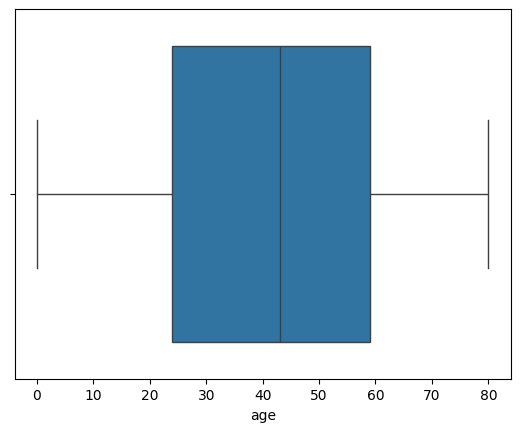

In [ ]:
sns.boxplot(x=df['age'])
plt.show()

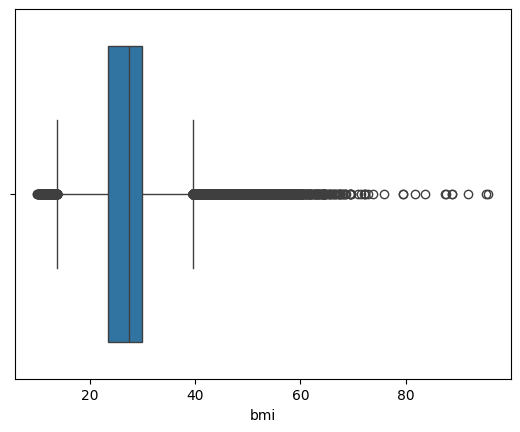

In [ ]:
sns.boxplot(x=df['bmi'])
plt.show()

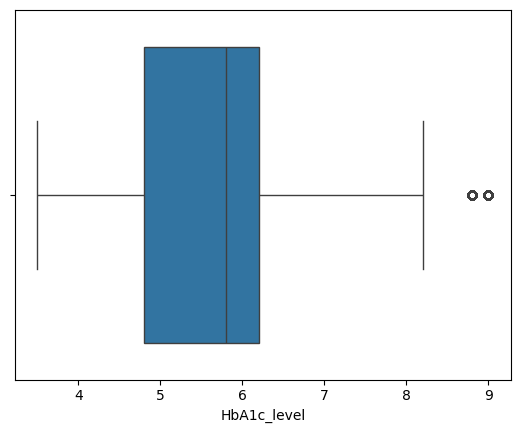

In [ ]:
sns.boxplot(x=df['HbA1c_level'])
plt.show()

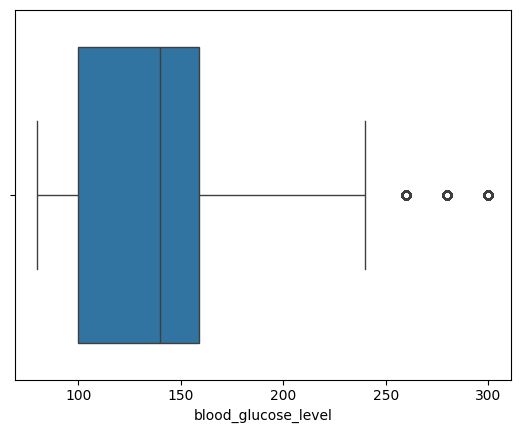

In [ ]:
sns.boxplot(x=df['blood_glucose_level'])
plt.show()

HISTOGRAM

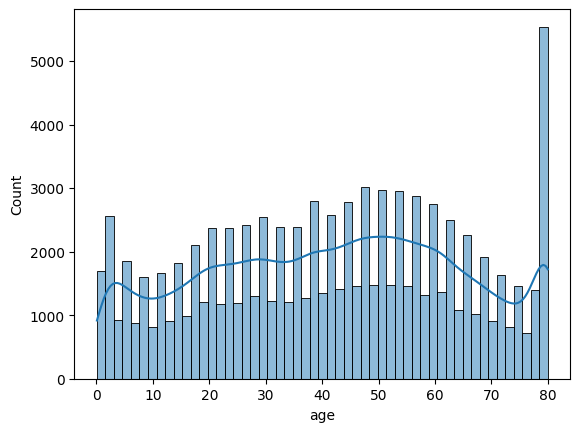

In [ ]:
sns.histplot(df['age'], kde=True)
plt.show()

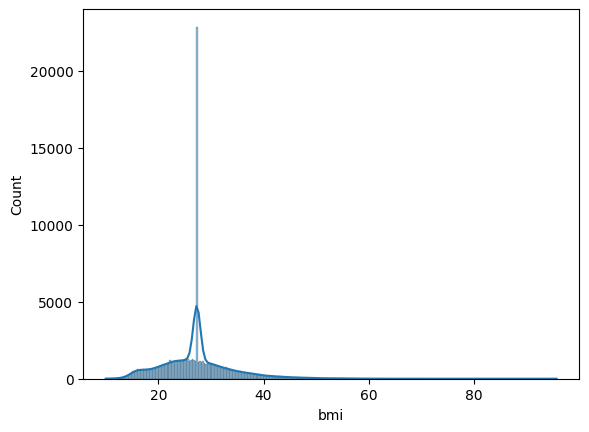

In [ ]:
sns.histplot(df['bmi'], kde=True)
plt.show()

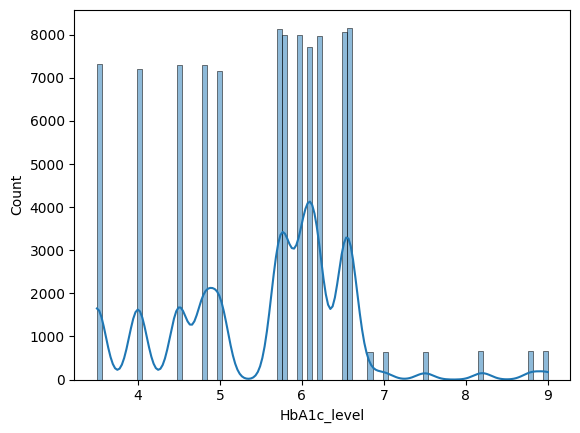

In [ ]:
sns.histplot(df['HbA1c_level'], kde=True)
plt.show()

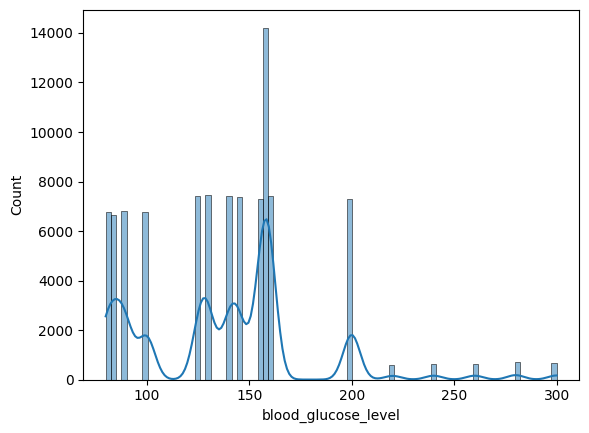

In [ ]:
sns.histplot(df['blood_glucose_level'], kde=True)
plt.show()

DETECT OUTLIERS USING ZSCORE METHOD

In [ ]:
from scipy.stats import zscore
age_z = np.abs(zscore(df['age']))
print("Age Outliers:", (age_z > 3). sum())

Age Outliers: 0


In [ ]:
bmi_z = np.abs(zscore(df['bmi']))
print("Bmi Outliers:", (bmi_z > 3). sum())

Bmi Outliers: 1211


In [ ]:
hba1c_z = np.abs(zscore(df['HbA1c_level']))

print("HbA1c outliers:", (hba1c_z > 3).sum())

HbA1c outliers: 1312


In [ ]:
glucose_z = np.abs(zscore(df['blood_glucose_level']))

print("Blood glucose outliers:", (glucose_z > 3).sum())

Blood glucose outliers: 1397


CATEGORICALL ENCODING

In [ ]:
print(df['gender'].value_counts())
print(df['smoking_history'].value_counts())

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


One-Hot Encoding

In [ ]:
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

In [ ]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   hypertension                 96146 non-null  int64  
 2   heart_disease                96146 non-null  int64  
 3   bmi                          96146 non-null  float64
 4   HbA1c_level                  96146 non-null  float64
 5   blood_glucose_level          96146 non-null  int64  
 6   diabetes                     96146 non-null  int64  
 7   gender_Male                  96146 non-null  bool   
 8   gender_Other                 96146 non-null  bool   
 9   smoking_history_current      96146 non-null  bool   
 10  smoking_history_ever         96146 non-null  bool   
 11  smoking_history_former       96146 non-null  bool   
 12  smoking_history_never        96146 non-null  bool   
 13  smoking_history_not c

SEPERATE TARGET Y AND FEATURES X

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [ ]:
print(X.shape)
print(y.shape)

(96146, 13)
(96146,)


TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

FINAL CHECK

In [ ]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (76916, 13)
Testing shape: (19230, 13)


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

diabetes
0    70130
1     6786
Name: count, dtype: int64
diabetes
0    17534
1     1696
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
gender_Male                    0
gender_Other                   0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


 APPLY LOGISTIC MODEL

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


EVALUATION MATRICS

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.9596463858554343
Precision: 0.8691813804173355
Recall: 0.6385613207547169
F1: 0.7362338545207342


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17371   163]
 [  613  1083]]


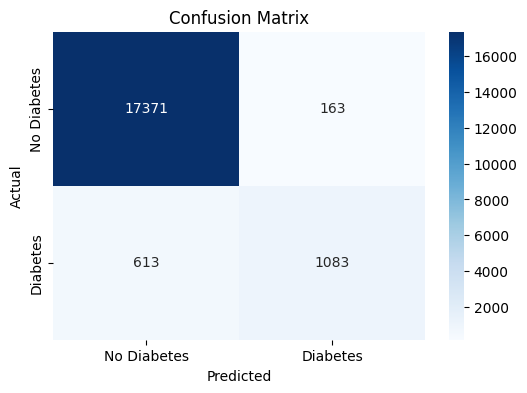

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230



In [ ]:
y_prob = model.predict_proba(X_test_scaled)

y_prob[:5]

array([[6.79273035e-01, 3.20726965e-01],
       [9.99988243e-01, 1.17568532e-05],
       [9.59009926e-01, 4.09900738e-02],
       [9.99744118e-01, 2.55881595e-04],
       [9.88535715e-01, 1.14642850e-02]])

Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)

Decision Tree Results
Accuracy: 0.9473738949557983
Precision: 0.6891592920353983
Recall: 0.7346698113207547
F1 Score: 0.7111872146118722


In [ ]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[16972   562]
 [  450  1246]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17534
           1       0.69      0.73      0.71      1696

    accuracy                           0.95     19230
   macro avg       0.83      0.85      0.84     19230
weighted avg       0.95      0.95      0.95     19230



KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN Results")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)

KNN Results
Accuracy: 0.9591783671346854
Precision: 0.8856900931414056
Recall: 0.6167452830188679
F1 Score: 0.727146332985749


In [ ]:
knn_cm = confusion_matrix(y_test, knn_pred)

print(knn_cm)

[[17399   135]
 [  650  1046]]


In [ ]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.89      0.62      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.96931877275091
Precision: 0.9488636363636364
Recall: 0.6892688679245284
F1 Score: 0.7984972677595629


In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[17471    63]
 [  527  1169]]


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        dt_accuracy,
        knn_accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        dt_precision,
        knn_precision,
        rf_precision
    ],

    "Recall": [
        recall,
        dt_recall,
        knn_recall,
        rf_recall
    ],

    "F1 Score": [
        f1,
        dt_f1,
        knn_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.959646,0.869181,0.638561,0.736234
1,Decision Tree,0.947374,0.689159,0.734670,0.711187
2,KNN,0.959178,0.885690,0.616745,0.727146
3,Random Forest,0.969319,0.948864,0.689269,0.798497


APPLY SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)
#train
svm_model.fit(
    X_train_scaled,
    y_train
)
#pred
svm_pred = svm_model.predict(
    X_test_scaled
)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Precision:",
      precision_score(y_test, svm_pred))

print("Recall:",
      recall_score(y_test, svm_pred))

print("F1 Score:",
      f1_score(y_test, svm_pred))

Accuracy: 0.9620384815392615
Precision: 0.9680232558139535
Recall: 0.5890330188679245
F1 Score: 0.7324046920821115


In [ ]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

print(cm)

[[17501    33]
 [  697   999]]


In [ ]:
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.97      0.59      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.96      0.79      0.86     19230
weighted avg       0.96      0.96      0.96     19230



In [ ]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred
)

svm_recall = recall_score(
    y_test,
    svm_pred
)

svm_f1 = f1_score(
    y_test,
    svm_pred
)
results.loc[len(results)] = [
    'SVM',
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.959646,0.869181,0.638561,0.736234
1,Decision Tree,0.947374,0.689159,0.734670,0.711187
2,KNN,0.959178,0.885690,0.616745,0.727146
3,Random Forest,0.969319,0.948864,0.689269,0.798497
4,SVM,0.962038,0.968023,0.589033,0.732405


Linear SVM now comapre kernels

In [ ]:
svm_linear = SVC(
    kernel = 'linear',
    random_state = 42
)

svm_linear.fit(X_train_scaled, y_train)
linear_pred  = svm_linear.predict(X_test_scaled)

In [ ]:
svm_poly = SVC(
    kernel='poly',
    random_state=42
)

svm_poly.fit(X_train_scaled, y_train)

poly_pred = svm_poly.predict(X_test_scaled)

In [ ]:
svm_rbf = SVC(
    kernel='rbf',
    random_state=42
)

svm_rbf.fit(X_train_scaled, y_train)

rbf_pred = svm_rbf.predict(X_test_scaled)

In [ ]:
print("Linear Accuracy:",
      accuracy_score(y_test, linear_pred))

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

Linear Accuracy: 0.9599063962558503
Polynomial Accuracy: 0.9632345293811753
RBF Accuracy: 0.9620384815392615


In [ ]:
svm_comparison = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF'],

    'Accuracy': [
        accuracy_score(y_test, linear_pred),
        accuracy_score(y_test, poly_pred),
        accuracy_score(y_test, rbf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, linear_pred),
        f1_score(y_test, poly_pred),
        f1_score(y_test, rbf_pred)
    ],
    'Recall': [
        recall_score(y_test, linear_pred),
        recall_score(y_test, poly_pred),
        recall_score(y_test, rbf_pred)

    ]
})

svm_comparison

,Kernel,Accuracy,F1 Score,Recall
0,Linear,0.959906,0.725525,0.600825
1,Polynomial,0.963235,0.740741,0.595519
2,RBF,0.962038,0.732405,0.589033


In [ ]:
from sklearn.model_selection import train_test_split

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=20000,
    random_state=42,
    stratify=y_train
)

In [ ]:
X_train_svm.shape

(20000, 13)

In [ ]:
c_values = [0.1, 1, 10]

svm_c_results = []

for c in c_values:

    model = SVC(
        kernel='rbf',
        C=c,
        gamma='scale',
        random_state=42
    )

    model.fit(X_train_svm, y_train_svm)

    pred = model.predict(X_test_scaled)

    svm_c_results.append({
        'C': c,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

svm_c_results = pd.DataFrame(svm_c_results)

svm_c_results

,C,Accuracy,Precision,Recall,F1 Score
0,0.1,0.957826,0.971246,0.537736,0.692220
1,1.0,0.960478,0.943182,0.587264,0.723837
2,10.0,0.961258,0.931097,0.605542,0.733834


In [ ]:
gamma_values = [0.01, 0.1, 1]

svm_gamma_results = []

for gamma in gamma_values:

    model = SVC(
        kernel='rbf',
        C=10,
        gamma=gamma,
        random_state=42
    )

    model.fit(X_train_svm, y_train_svm)

    pred = model.predict(X_test_scaled)

    svm_gamma_results.append({
        'Gamma': gamma,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

svm_gamma_results = pd.DataFrame(svm_gamma_results)

svm_gamma_results

,Gamma,Accuracy,Precision,Recall,F1 Score
0,0.01,0.961050,0.946277,0.591981,0.728328
1,0.10,0.961310,0.928058,0.608491,0.735043
2,1.00,0.951534,0.812092,0.586085,0.680822


Voting Classifier — Hard Voting Ensemble learning

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

hard_voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(kernel='rbf', random_state=42))
    ],
    voting='hard'
)

hard_voting_model.fit(X_train_scaled, y_train)

hard_pred = hard_voting_model.predict(X_test_scaled)

hard_accuracy = accuracy_score(y_test, hard_pred)
hard_precision = precision_score(y_test, hard_pred)
hard_recall = recall_score(y_test, hard_pred)
hard_f1 = f1_score(y_test, hard_pred)

print("Hard Voting Results")
print("Accuracy:", hard_accuracy)
print("Precision:", hard_precision)
print("Recall:", hard_recall)
print("F1 Score:", hard_f1)

Hard Voting Results
Accuracy: 0.9634945397815913
Precision: 0.9778846153846154
Recall: 0.5996462264150944
F1 Score: 0.743421052631579


soft voting

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

soft_voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('dt', DecisionTreeClassifier(random_state=42))
    ],
    voting='soft'
)

soft_voting_model.fit(X_train_scaled, y_train)

soft_pred = soft_voting_model.predict(X_test_scaled)

soft_accuracy = accuracy_score(y_test, soft_pred)
soft_precision = precision_score(y_test, soft_pred)
soft_recall = recall_score(y_test, soft_pred)
soft_f1 = f1_score(y_test, soft_pred)

print("Soft Voting Results")
print("Accuracy:", soft_accuracy)
print("Precision:", soft_precision)
print("Recall:", soft_recall)
print("F1 Score:", soft_f1)

Soft Voting Results
Accuracy: 0.9627145085803432
Precision: 0.8672168042010503
Recall: 0.6816037735849056
F1 Score: 0.7632882139319908


Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_pred)
ada_precision = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)
ada_f1 = f1_score(y_test, ada_pred)

print("AdaBoost Results")
print("Accuracy:", ada_accuracy)
print("Precision:", ada_precision)
print("Recall:", ada_recall)
print("F1 Score:", ada_f1)

AdaBoost Results
Accuracy: 0.971606864274571
Precision: 1.0
Recall: 0.6780660377358491
F1 Score: 0.8081517919887562


Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

Gradient Boosting Results
Accuracy: 0.9718148725949038
Precision: 0.9865092748735245
Recall: 0.6898584905660378
F1 Score: 0.8119361554476058


Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model.fit(X_train_scaled, y_train)

stacking_pred = stacking_model.predict(X_test_scaled)

stacking_accuracy = accuracy_score(y_test, stacking_pred)
stacking_precision = precision_score(y_test, stacking_pred)
stacking_recall = recall_score(y_test, stacking_pred)
stacking_f1 = f1_score(y_test, stacking_pred)

print("Stacking Results")
print("Accuracy:", stacking_accuracy)
print("Precision:", stacking_precision)
print("Recall:", stacking_recall)
print("F1 Score:", stacking_f1)

Stacking Results
Accuracy: 0.9643785751430057
Precision: 0.9040767386091128
Recall: 0.6668632075471698
F1 Score: 0.7675602307431286


In [ ]:
ensemble_results = pd.DataFrame({
    'Model': [
        'Hard Voting',
        'Soft Voting',
        'AdaBoost',
        'Gradient Boosting',
        'Stacking'
    ],
    'Accuracy': [
        hard_accuracy,
        soft_accuracy,
        ada_accuracy,
        gb_accuracy,
        stacking_accuracy
    ],
    'Precision': [
        hard_precision,
        soft_precision,
        ada_precision,
        gb_precision,
        stacking_precision
    ],
    'Recall': [
        hard_recall,
        soft_recall,
        ada_recall,
        gb_recall,
        stacking_recall
    ],
    'F1 Score': [
        hard_f1,
        soft_f1,
        ada_f1,
        gb_f1,
        stacking_f1
    ]
})

ensemble_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,0.963495,0.977885,0.599646,0.743421
1,Soft Voting,0.962715,0.867217,0.681604,0.763288
2,AdaBoost,0.971607,1.000000,0.678066,0.808152
3,Gradient Boosting,0.971815,0.986509,0.689858,0.811936
4,Stacking,0.964379,0.904077,0.666863,0.767560


In [ ]:
final_results = pd.concat(
    [results, ensemble_results],
    ignore_index=True
)

final_results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
8,Gradient Boosting,0.971815,0.986509,0.689858,0.811936
7,AdaBoost,0.971607,1.000000,0.678066,0.808152
3,Random Forest,0.969319,0.948864,0.689269,0.798497
9,Stacking,0.964379,0.904077,0.666863,0.767560
6,Soft Voting,0.962715,0.867217,0.681604,0.763288
5,Hard Voting,0.963495,0.977885,0.599646,0.743421
0,Logistic Regression,0.959646,0.869181,0.638561,0.736234
4,SVM,0.962038,0.968023,0.589033,0.732405
2,KNN,0.959178,0.885690,0.616745,0.727146
1,Decision Tree,0.947374,0.689159,0.734670,0.711187


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, gb_pred)
print(cm)

Accuracy: 0.9718148725949038
Precision: 0.9865092748735245
Recall: 0.6898584905660378
F1 Score: 0.8119361554476058

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.99      0.69      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230


Confusion Matrix:

[[17518    16]
 [  526  1170]]


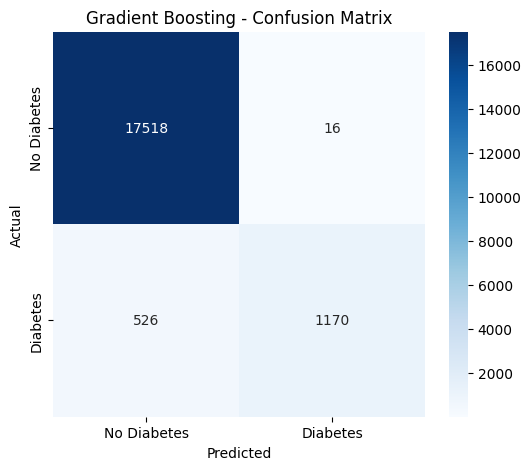

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting - Confusion Matrix')

plt.show()

Actual vs Predicted Values

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': gb_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
gb_prob = gb_model.predict_proba(X_test)

print(gb_prob[:10])

[[8.80959642e-01 1.19040358e-01]
 [9.99203994e-01 7.96006404e-04]
 [9.95232133e-01 4.76786664e-03]
 [9.98650626e-01 1.34937392e-03]
 [9.98671931e-01 1.32806919e-03]
 [9.97463254e-01 2.53674597e-03]
 [9.98469886e-01 1.53011360e-03]
 [9.98528789e-01 1.47121083e-03]
 [9.23246115e-01 7.67538855e-02]
 [9.97814434e-01 2.18556620e-03]]


Actual + Predicted + Probability table

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': gb_pred,
    'Probability_Diabetes': gb_prob[:, 1]
})

comparison.head(20)

,Actual,Predicted,Probability_Diabetes
0,0,0,0.119040
1,0,0,0.000796
2,0,0,0.004768
3,0,0,0.001349
4,0,0,0.001328
5,0,0,0.002537
6,0,0,0.001530
7,0,0,0.001471
8,0,0,0.076754
9,0,0,0.002186


In [ ]:
final_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

In [ ]:
import pandas as pd

random_examples = X_test.sample(10, random_state=42)

random_predictions = final_model.predict(random_examples)

random_probabilities = final_model.predict_proba(random_examples)[:, 1]

real_examples_results = random_examples.copy()

real_examples_results['Actual_Diabetes'] = y_test.loc[random_examples.index]
real_examples_results['Predicted_Diabetes'] = random_predictions
real_examples_results['Diabetes_Probability'] = random_probabilities

real_examples_results

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,Actual_Diabetes,Predicted_Diabetes,Diabetes_Probability
36061,31.0,0,0,27.40,4.0,80,True,False,False,False,True,False,False,0,0,0.000577
29824,35.0,0,0,27.32,6.6,140,False,False,False,False,False,False,False,0,0,0.016465
29668,48.0,0,0,26.27,6.6,160,True,False,False,False,False,True,False,0,0,0.046160
11816,67.0,0,0,25.28,4.8,90,False,False,False,False,True,False,False,0,0,0.001272
99242,67.0,0,0,30.29,4.5,90,False,False,False,False,False,False,False,0,0,0.000660
26718,38.0,0,0,27.32,6.5,85,False,False,False,False,False,False,False,0,0,0.001362
53059,63.0,0,0,22.70,4.5,100,False,False,False,False,False,True,False,0,0,0.001455
69294,66.0,0,0,31.72,3.5,80,True,False,False,False,False,True,False,0,0,0.000703
8912,55.0,0,0,58.16,6.0,85,True,False,False,False,False,True,False,0,0,0.011157
37072,18.0,0,0,28.27,5.0,155,False,False,False,False,False,True,False,0,0,0.001546


In [ ]:
real_examples_results['Actual_Result'] = real_examples_results[
    'Actual_Diabetes'
].map({
    0: 'No Diabetes',
    1: 'Diabetes'
})

real_examples_results['Predicted_Result'] = real_examples_results[
    'Predicted_Diabetes'
].map({
    0: 'No Diabetes',
    1: 'Diabetes'
})

real_examples_results[
    [
        'age',
        'bmi',
        'HbA1c_level',
        'blood_glucose_level',
        'Actual_Result',
        'Predicted_Result',
        'Diabetes_Probability'
    ]
]

,age,bmi,HbA1c_level,blood_glucose_level,Actual_Result,Predicted_Result,Diabetes_Probability
36061,31.0,27.40,4.0,80,No Diabetes,No Diabetes,0.000577
29824,35.0,27.32,6.6,140,No Diabetes,No Diabetes,0.016465
29668,48.0,26.27,6.6,160,No Diabetes,No Diabetes,0.046160
11816,67.0,25.28,4.8,90,No Diabetes,No Diabetes,0.001272
99242,67.0,30.29,4.5,90,No Diabetes,No Diabetes,0.000660
26718,38.0,27.32,6.5,85,No Diabetes,No Diabetes,0.001362
53059,63.0,22.70,4.5,100,No Diabetes,No Diabetes,0.001455
69294,66.0,31.72,3.5,80,No Diabetes,No Diabetes,0.000703
8912,55.0,58.16,6.0,85,No Diabetes,No Diabetes,0.011157
37072,18.0,28.27,5.0,155,No Diabetes,No Diabetes,0.001546


In [ ]:
real_diabetes_examples = X_test[y_test == 1].sample(
    10,
    random_state=42
)

predictions = final_model.predict(real_diabetes_examples)

probabilities = final_model.predict_proba(
    real_diabetes_examples
)[:, 1]

results = real_diabetes_examples.copy()

results['Actual'] = 1
results['Predicted'] = predictions
results['Diabetes_Probability'] = probabilities

results

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,Actual,Predicted,Diabetes_Probability
66536,78.0,0,0,27.32,5.8,126,False,False,False,False,False,False,True,1,0,0.100991
18159,49.0,0,1,47.30,7.0,155,False,False,False,False,False,True,False,1,1,0.996900
71867,65.0,0,0,28.22,6.0,155,False,False,False,False,False,True,False,1,0,0.093090
78414,59.0,0,0,33.99,6.0,260,True,False,False,False,False,True,False,1,1,0.991689
5550,80.0,0,1,27.80,8.8,145,True,False,False,False,True,False,False,1,1,0.995238
30827,26.0,0,0,29.89,8.8,260,False,False,False,False,False,False,True,1,1,0.996761
7089,59.0,0,0,27.32,6.8,130,False,False,False,False,False,False,False,1,1,0.991699
85940,80.0,1,0,29.37,9.0,280,False,False,False,True,False,False,False,1,1,0.996157
3892,73.0,0,0,25.20,6.2,300,True,False,False,False,False,True,False,1,1,0.993844
96286,38.0,0,0,23.67,8.8,145,False,False,False,True,False,False,False,1,1,0.987054


In [ ]:
patient = X_test.sample(1, random_state=100)

actual_value = y_test.loc[patient.index].iloc[0]

prediction = final_model.predict(patient)[0]

probability = final_model.predict_proba(patient)[0][1]

print("Patient Data:")
print(patient)

print("\nActual:", actual_value)
print("Predicted:", prediction)
print("Diabetes Probability:", probability)

Patient Data:
        age  hypertension  heart_disease    bmi  HbA1c_level  \
91906  48.0             0              0  29.15          5.7   

       blood_glucose_level  gender_Male  gender_Other  \
91906                  300         True         False   

       smoking_history_current  smoking_history_ever  smoking_history_former  \
91906                     True                 False                   False   

       smoking_history_never  smoking_history_not current  
91906                  False                        False  

Actual: 1
Predicted: 1
Diabetes Probability: 0.9898228880651596


In [ ]:
test_patients = pd.DataFrame([

    # Patient 1
    {
        'age': 30,
        'hypertension': 0,
        'heart_disease': 0,
        'bmi': 22.5,
        'HbA1c_level': 4.8,
        'blood_glucose_level': 90,
        'gender_Male': 1,
        'gender_Other': 0,
        'smoking_history_current': 0,
        'smoking_history_ever': 0,
        'smoking_history_former': 0,
        'smoking_history_never': 1,
        'smoking_history_not current': 0
    },

    # Patient 2
    {
        'age': 55,
        'hypertension': 1,
        'heart_disease': 0,
        'bmi': 32.0,
        'HbA1c_level': 7.5,
        'blood_glucose_level': 200,
        'gender_Male': 0,
        'gender_Other': 0,
        'smoking_history_current': 0,
        'smoking_history_ever': 0,
        'smoking_history_former': 1,
        'smoking_history_never': 0,
        'smoking_history_not current': 0
    },

    # Patient 3
    {
        'age': 70,
        'hypertension': 1,
        'heart_disease': 1,
        'bmi': 35.0,
        'HbA1c_level': 8.0,
        'blood_glucose_level': 250,
        'gender_Male': 1,
        'gender_Other': 0,
        'smoking_history_current': 1,
        'smoking_history_ever': 0,
        'smoking_history_former': 0,
        'smoking_history_never': 0,
        'smoking_history_not current': 0
    }
])

test_patients = test_patients.reindex(columns=X.columns, fill_value=0)

predictions = final_model.predict(test_patients)

probabilities = final_model.predict_proba(test_patients)[:, 1]

for i in range(len(test_patients)):

    print(f"\nPatient {i+1}")

    if predictions[i] == 1:
        print("Prediction: Diabetes")
    else:
        print("Prediction: No Diabetes")

    print("Diabetes Probability:", probabilities[i])


Patient 1
Prediction: No Diabetes
Diabetes Probability: 0.0008626057015641892

Patient 2
Prediction: Diabetes
Diabetes Probability: 0.9931294933045086

Patient 3
Prediction: Diabetes
Diabetes Probability: 0.9967217037761813


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "diabetes_model.pkl":
            print("MODEL FOUND:", os.path.join(root, file))

MODEL FOUND: /content/drive/MyDrive/Diabetes_ML_Project/diabetes_model.pkl


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.5 MB/s eta 0:00:00


In [3]:
import joblib

model = joblib.load(
    "/content/drive/MyDrive/Diabetes_ML_Project/diabetes_model.pkl"
)

print(model)

GradientBoostingClassifier(random_state=42)


app.py


In [4]:
%%writefile /content/drive/MyDrive/Diabetes_ML_Project/app.py

import streamlit as st
import pandas as pd
import joblib
from pathlib import Path
import os

# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Diabetes Prediction System",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# LOAD MODEL
# =========================================================

MODEL_PATH = os.path.join(
    os.path.dirname(__file__),
    "diabetes_model.pkl"
)

@st.cache_resource
def load_model():
    return joblib.load("diabetes_model.pkl")

model = load_model()
# =========================================================
# SESSION STATE
# =========================================================

if "prediction_made" not in st.session_state:
    st.session_state.prediction_made = False

if "prediction" not in st.session_state:
    st.session_state.prediction = None

if "probability" not in st.session_state:
    st.session_state.probability = None

# CSS
# =========================================================

st.markdown("""
<style>

/* MAIN APP */

.stApp {
    background:
        radial-gradient(circle at 75% 10%, rgba(80, 100, 255, 0.16), transparent 28%),
        radial-gradient(circle at 15% 75%, rgba(0, 200, 255, 0.08), transparent 30%),
        #08111f;
    color: white;
}


/* MAIN CONTAINER */

.block-container {
    max-width: 1500px;
    padding-top: 2rem;
    padding-bottom: 1rem;
}


/* REMOVE DEFAULT ELEMENTS */

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

header {
    background: transparent !important;
}


/* GLOBAL TEXT */

h1, h2, h3, h4, h5, p, span, label {
    color: #f4f7fb !important;
}


/* SIDEBAR */

[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0b1728, #08111f);
    border-right: 1px solid #1d3555;
}

[data-testid="stSidebar"] * {
    color: #dbe7f5 !important;
}


/* RADIO */

[data-testid="stSidebar"] .stRadio label {
    background: transparent;
    padding: 10px;
    border-radius: 10px;
}


/* INPUT LABELS */

[data-testid="stWidgetLabel"] p {
    color: #ffffff !important;
    font-size: 15px !important;
    font-weight: 600 !important;
}


/* NUMBER INPUT */

[data-testid="stNumberInput"] input {
    background-color: #111e33 !important;
    color: #ffffff !important;
    border: 1px solid #2c486d !important;
    border-radius: 10px !important;
}


/* SELECT BOX */

[data-baseweb="select"] > div {
    background-color: #111e33 !important;
    color: #ffffff !important;
    border: 1px solid #2c486d !important;
    border-radius: 10px !important;
    min-height: 48px !important;
}

[data-baseweb="select"] * {
    color: #ffffff !important;
}


/* DROPDOWN */

[role="listbox"] {
    background-color: #111e33 !important;
}

[role="option"] {
    background-color: #111e33 !important;
    color: white !important;
}

[role="option"]:hover {
    background-color: #1d3150 !important;
}


/* BUTTON */

.stButton > button {
    width: 100%;
    min-height: 58px;
    border: none;
    border-radius: 12px;
    background: linear-gradient(90deg, #3867e8, #7042dc);
    color: white !important;
    font-size: 17px;
    font-weight: 700;
    box-shadow: 0 10px 25px rgba(75, 80, 255, 0.3);
    transition: 0.3s;
}

.stButton > button:hover {
    transform: translateY(-2px);
    background: linear-gradient(90deg, #4b7dff, #875cff);
}


/* CARDS */

.dashboard-card {
    background: linear-gradient(
        145deg,
        rgba(22, 37, 62, 0.98),
        rgba(11, 23, 42, 0.98)
    );
    border: 1px solid rgba(87, 142, 210, 0.25);
    border-radius: 20px;
    padding: 25px;
    box-shadow: 0 12px 35px rgba(0, 0, 0, 0.2);
}


/* HERO */

.hero-container {
    position: relative;
    overflow: hidden;
    min-height: 155px;
    border-radius: 20px;
    padding: 30px;
    margin-bottom: 25px;
    background: linear-gradient(
        100deg,
        rgba(13, 27, 48, 0.9),
        rgba(20, 34, 65, 0.6)
    );
    border: 1px solid rgba(85, 140, 220, 0.2);
}

.hero-title {
    color: white !important;
    font-size: 38px;
    font-weight: 700;
    margin: 0;
}

.gradient-text {
    background: linear-gradient(90deg, #63a8ff, #70e4d1);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-subtitle {
    color: #b7c5d8 !important;
    font-size: 17px;
    margin-top: 10px;
}


/* ANIMATED HEART */

.hero-heart {
    position: absolute;
    right: 7%;
    top: 25px;
    font-size: 82px;
    filter: drop-shadow(0 0 25px rgba(90, 150, 255, 0.9));
    animation: heartbeat 1.8s infinite;
}

.hero-glow {
    position: absolute;
    right: 4%;
    top: 10px;
    width: 220px;
    height: 120px;
    background: radial-gradient(
        ellipse,
        rgba(80, 100, 255, 0.25),
        transparent 70%
    );
    animation: glow 3s infinite alternate;
}

.ecg {
    position: absolute;
    right: 3%;
    bottom: 18px;
    width: 320px;
    height: 3px;
    background: linear-gradient(
        90deg,
        transparent,
        #3eb8ff,
        #7b6cff,
        #54e0d0,
        transparent
    );
    box-shadow: 0 0 15px #48a9ff;
    animation: ecgmove 2.5s infinite;
}


/* RESULT CIRCLE */

.result-circle {
    width: 270px;
    height: 270px;
    border-radius: 50%;
    margin: 20px auto;
    display: flex;
    flex-direction: column;
    justify-content: center;
    align-items: center;
    background: radial-gradient(circle, #162640, #0c1729);
    border: 7px solid #4b86e8;
    box-shadow:
        0 0 35px rgba(78, 135, 240, 0.35),
        inset 0 0 35px rgba(55, 100, 180, 0.15);
    animation: resultPulse 3s infinite;
}


/* INFO BOX */

.info-box {
    padding: 18px;
    border-radius: 14px;
    background: rgba(24, 42, 70, 0.8);
    border: 1px solid rgba(100, 160, 255, 0.2);
    color: #c8d5e8 !important;
    text-align: center;
}


/* STATS */

.stat-box {
    text-align: center;
    padding: 10px;
}

.stat-number {
    font-size: 25px;
    font-weight: 700;
    color: #ffffff !important;
}

.stat-label {
    color: #9eafc5 !important;
    font-size: 13px;
}


/* METRICS */

[data-testid="stMetric"] {
    background: #111e33;
    border: 1px solid #294664;
    padding: 16px;
    border-radius: 14px;
}

[data-testid="stMetricLabel"] {
    color: #b8c7da !important;
}

[data-testid="stMetricValue"] {
    color: #72e3d1 !important;
}


/* ANIMATIONS */

@keyframes heartbeat {
    0%, 100% {
        transform: scale(1);
    }

    50% {
        transform: scale(1.15);
    }
}

@keyframes glow {
    from {
        transform: scale(0.9);
        opacity: 0.5;
    }

    to {
        transform: scale(1.2);
        opacity: 1;
    }
}

@keyframes ecgmove {
    0%, 100% {
        opacity: 0.4;
        transform: scaleX(0.7);
    }

    50% {
        opacity: 1;
        transform: scaleX(1);
    }
}

@keyframes resultPulse {
    0%, 100% {
        box-shadow:
            0 0 25px rgba(78, 135, 240, 0.3),
            inset 0 0 30px rgba(55, 100, 180, 0.1);
    }

    50% {
        box-shadow:
            0 0 50px rgba(100, 220, 210, 0.4),
            inset 0 0 40px rgba(55, 100, 180, 0.2);
    }
}


/* FOOTER */

.footer {
    text-align: center;
    padding: 28px 0;
    color: #9fb1c7 !important;
}


/* MOBILE */

@media (max-width: 900px) {
    .hero-heart {
        opacity: 0.25;
    }

    .ecg {
        opacity: 0.2;
    }

    .hero-title {
        font-size: 28px;
    }
}

</style>
""", unsafe_allow_html=True)

# SIDEBAR
# =========================================================

with st.sidebar:

    st.markdown("""
<h2 style="margin-bottom:0;">🩺 Diabetes</h2>
<p style="color:#62c8ff !important; margin-top:0;">
Prediction System
</p>
""", unsafe_allow_html=True)

    st.write("")

    page = st.radio(
        "Navigation",
        [
            "Prediction",
            "Dashboard",
            "Data Insights",
            "Model Performance",
            "About"
        ],
        label_visibility="collapsed"
    )

    st.markdown("""
<div class="dashboard-card" style="text-align:center; margin-top:30px;">
<div style="font-size:75px; animation:heartbeat 2s infinite;">
🩺
</div>
<h3 style="color:#69d9e8 !important;">
Early Prediction
</h3>
<h3 style="color:#69d9e8 !important;">
Better Prevention
</h3>
<p style="color:#aab9cb !important;">
Make smarter health decisions with AI.
</p>
</div>
""", unsafe_allow_html=True)

# HERO HEADER
# IMPORTANT: NO INDENTATION INSIDE HTML
# =========================================================

st.markdown("""
<div class="hero-container">
<div class="hero-glow"></div>
<div class="hero-heart">💜</div>
<div class="ecg"></div>

<h1 class="hero-title">
Welcome to
<span class="gradient-text">
Diabetes Prediction System
</span>
</h1>

<p class="hero-subtitle">
Enter patient details to predict the likelihood of diabetes using Machine Learning.
</p>

</div>
""", unsafe_allow_html=True)


# PREDICTION PAGE
# =========================================================

if page == "Prediction":

    left, right = st.columns([1.05, 0.95], gap="large")

    with left:

        st.markdown("""
<div class="dashboard-card">
<h2 style="margin:0;">🪪 Patient Information</h2>
<p style="color:#9fb1c7 !important;">
Enter the patient details below
</p>
</div>
""", unsafe_allow_html=True)

        st.write("")

        col1, col2 = st.columns(2)

        with col1:
            gender = st.selectbox(
                "👤 Gender",
                ["Female", "Male", "Other"]
            )

        with col2:
            age = st.number_input(
                "👤 Age",
                min_value=1.0,
                max_value=120.0,
                value=45.0,
                step=1.0
            )

        col3, col4 = st.columns(2)

        with col3:
            hypertension_text = st.selectbox(
                "♡ Hypertension",
                ["No", "Yes"]
            )

        with col4:
            heart_text = st.selectbox(
                "♡ Heart Disease",
                ["No", "Yes"]
            )

        col5, col6 = st.columns(2)

        with col5:
            smoking_history = st.selectbox(
                "☰ Smoking History",
                [
                    "No Info",
                    "Never",
                    "Former",
                    "Current",
                    "Ever",
                    "Not Current"
                ]
            )

        with col6:
            bmi = st.number_input(
                "⚖ BMI",
                min_value=10.0,
                max_value=100.0,
                value=28.5,
                step=0.1
            )

        col7, col8 = st.columns(2)

        with col7:
            hba1c = st.number_input(
                "🧪 HbA1c Level (%)",
                min_value=3.0,
                max_value=15.0,
                value=6.5,
                step=0.1
            )

        with col8:
            blood_glucose = st.number_input(
                "🔥 Blood Glucose Level (mg/dL)",
                min_value=50,
                max_value=500,
                value=150,
                step=1
            )

        st.write("")

        predict_button = st.button(
            "🧠 Predict Diabetes",
            use_container_width=True
        )

        st.caption(" All fields are required for prediction")

    with right:

        st.markdown("""
<div class="dashboard-card">
<h2 style="margin:0;">🏆 Prediction Result</h2>
<p style="color:#9fb1c7 !important;">
AI Machine Learning prediction
</p>
</div>
""", unsafe_allow_html=True)

        if not st.session_state.prediction_made:

            st.markdown("""
<div class="result-circle">
<div style="font-size:55px;">🩺</div>
<div style="font-size:25px; font-weight:700; color:#ffffff !important;">
Ready for Prediction
</div>
<p style="color:#a9b8ca !important; text-align:center;">
Enter patient details and click Predict Diabetes
</p>
</div>
""", unsafe_allow_html=True)

            st.markdown("""
<div class="info-box">
🤖 Trained Gradient Boosting Machine Learning model
will analyze the patient information and generate a prediction.
</div>
""", unsafe_allow_html=True)


    # =====================================================
    # PREDICTION
    # =====================================================

    if predict_button:

        if model is None:
            st.error("Model file diabetes_model.pkl was not found.")

        else:

            hypertension = 1 if hypertension_text == "Yes" else 0
            heart_disease = 1 if heart_text == "Yes" else 0

            patient_data = {
                "age": age,
                "hypertension": hypertension,
                "heart_disease": heart_disease,
                "bmi": bmi,
                "HbA1c_level": hba1c,
                "blood_glucose_level": blood_glucose,
                "gender_Male": 1 if gender == "Male" else 0,
                "gender_Other": 1 if gender == "Other" else 0,
                "smoking_history_current": 1 if smoking_history == "Current" else 0,
                "smoking_history_ever": 1 if smoking_history == "Ever" else 0,
                "smoking_history_former": 1 if smoking_history == "Former" else 0,
                "smoking_history_never": 1 if smoking_history == "Never" else 0,
                "smoking_history_not current": 1 if smoking_history == "Not Current" else 0
            }

            input_data = pd.DataFrame([patient_data])

            if hasattr(model, "feature_names_in_"):

                expected_features = list(model.feature_names_in_)

                for feature in expected_features:
                    if feature not in input_data.columns:
                        input_data[feature] = 0

                input_data = input_data[expected_features]

            try:

                prediction = model.predict(input_data)[0]

                probability = 0

                if hasattr(model, "predict_proba"):
                    probability = model.predict_proba(
                        input_data
                    )[0][1] * 100

                st.session_state.prediction = prediction
                st.session_state.probability = probability
                st.session_state.prediction_made = True

                st.rerun()

            except Exception as e:
                st.error("Prediction error occurred:")
                st.code(str(e))



    # SHOW SAVED RESULT
    # =====================================================

    if st.session_state.prediction_made:

        prediction = st.session_state.prediction
        probability = st.session_state.probability

        with right:

            if prediction == 1:
                result = "Diabetes Positive"
                result_color = "#ff8b8b"
                result_icon = "⚠️"
                description = (
                    "The model predicts a higher likelihood "
                    "of diabetes."
                )
            else:
                result = "Diabetes Negative"
                result_color = "#70e7c0"
                result_icon = "✓"
                description = (
                    "The model predicts a lower likelihood "
                    "of diabetes."
                )

            st.markdown(f"""
<div class="result-circle">
<div style="font-size:45px;">{result_icon}</div>

<div style="
font-size:28px;
font-weight:800;
color:{result_color} !important;
text-align:center;
margin-top:10px;
">
{result}
</div>

<p style="
color:#c7d3e2 !important;
text-align:center;
padding:0 20px;
">
{description}
</p>
</div>
""", unsafe_allow_html=True)

            st.metric(
                "📊 Diabetes Probability",
                f"{probability:.2f}%"
            )

            st.progress(
                min(max(int(probability), 0), 100)
            )

            st.write("")

            metric1, metric2 = st.columns(2)

            with metric1:
                st.metric(
                    "✓ Prediction",
                    "Positive" if prediction == 1 else "Negative"
                )

            with metric2:
                confidence = (
                    "High"
                    if probability >= 70 or probability <= 30
                    else "Medium"
                )

                st.metric(
                    "🛡 Model Confidence",
                    confidence
                )

            st.markdown("""
<div style="
margin-top:20px;
padding:15px;
border-radius:12px;
background:rgba(130,90,20,0.18);
border:1px solid rgba(255,180,70,0.25);
color:#f5c46b !important;
text-align:center;
">
⚠️ This prediction is for educational purposes only and should
not replace professional medical advice.
</div>
""", unsafe_allow_html=True)


    # BOTTOM STATISTICS
    # =====================================================

    st.write("")
    st.write("")

    stat1, stat2, stat3, stat4 = st.columns(4)

    with stat1:
        st.markdown("""
<div class="dashboard-card stat-box">
<div class="stat-number">👥 100,000+</div>
<div class="stat-label">Records Analyzed</div>
</div>
""", unsafe_allow_html=True)

    with stat2:
        st.markdown("""
<div class="dashboard-card stat-box">
<div class="stat-number">🎯 10</div>
<div class="stat-label">ML Models Used</div>
</div>
""", unsafe_allow_html=True)

    with stat3:
        st.markdown("""
<div class="dashboard-card stat-box">
<div class="stat-number">📈 97.18%</div>
<div class="stat-label">Best Accuracy</div>
</div>
""", unsafe_allow_html=True)

    with stat4:
        st.markdown("""
<div class="dashboard-card stat-box">
<div class="stat-number">🛡 High</div>
<div class="stat-label">Model Reliability</div>
</div>
""", unsafe_allow_html=True)


# =========================================================
# OTHER PAGES
# =========================================================

elif page == "Dashboard":

    st.title("📊 Dashboard")

    st.markdown("""
<div class="dashboard-card">
<h2>Project Overview</h2>
<p>
This Diabetes Prediction System analyzes patient health data
using Machine Learning.
</p>
</div>
""", unsafe_allow_html=True)


elif page == "Data Insights":

    st.title("📊 Data Insights")

    st.info(
        "EDA and dataset visualizations can be added here."
    )


elif page == "Model Performance":

    st.title("📈 Model Performance")

    performance = pd.DataFrame({
        "Model": [
            "Gradient Boosting",
            "AdaBoost",
            "Random Forest",
            "Stacking",
            "SVM",
            "Logistic Regression",
            "KNN",
            "Decision Tree"
        ],
        "Accuracy": [
            "97.18%",
            "97.16%",
            "96.93%",
            "96.44%",
            "96.20%",
            "95.96%",
            "95.92%",
            "94.74%"
        ]
    })

    st.dataframe(
        performance,
        use_container_width=True,
        hide_index=True
    )


elif page == "About":

    st.title("ⓘ About This Project")

    st.markdown("""
<div class="dashboard-card">
<h2>Diabetes Prediction System</h2>

<p>
This project was developed using Machine Learning to predict
the likelihood of diabetes based on patient health information.
</p>

<p>
Multiple classification models were implemented, evaluated
and compared.
</p>

<p>
🏆 Best Model: Gradient Boosting<br>
📈 Best Accuracy: 97.18%
</p>

<p>
Developed by <b style="color:#65cfff;">Shiza Eman</b>
</p>
</div>
""", unsafe_allow_html=True)

# FOOTER
# =========================================================

st.markdown("""
<div class="footer">

Developed by
<b style="color:#65cfff !important;">
Shiza Eman
</b>

&nbsp; | &nbsp;

AI-Powered Healthcare Intelligence

</div>
""", unsafe_allow_html=True)

Overwriting /content/drive/MyDrive/Diabetes_ML_Project/app.py


requirements.txt

In [5]:
%%writefile /content/drive/MyDrive/Diabetes_ML_Project/requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting /content/drive/MyDrive/Diabetes_ML_Project/requirements.txt


In [6]:
!ls /content/drive/MyDrive/Diabetes_ML_Project

app.py	diabetes_model.pkl  requirements.txt


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run /content/drive/MyDrive/Diabetes_ML_Project/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

In [ ]:
!cat /content/streamlit.log



2026-08-25 12:17:33.319 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.41.21.78:8501

